# 04 — Exploración: Proveedores Registrados SECOP II

**Fuente**: `proveedoresRegistrados` (Dataset ID: `qmzu-gj57`)  
**Granularidad**: 1 fila = 1 proveedor registrado en SECOP II  
**Columnas disponibles**: 25  

**Objetivo**: Explorar el perfil de los proveedores que participan en contratos de Obra Pública,
identificando variables útiles para el modelo predictivo (tipo de empresa, tamaño, ubicación,
categoría UNSPSC, estado de actividad).

**Llave de integración**: `codigo` (proveedores) → `codigo_proveedor` (contratosElectronicos)

| Campo API esperado | Tipo | Descripción |
|---|---|---|
| codigo | Texto | ID del proveedor en SECOP II |
| nombre | Texto | Nombre del proveedor |
| nit | Texto | Número de Identificación Tributaria |
| tipo_empresa | Texto | Tipo declarado por el proveedor |
| espyme | Texto | Clasificación Pyme |
| es_grupo | Texto | Pertenece a un grupo |
| es_entidad | Texto | También es entidad compradora |
| esta_activa | Texto | Estado de actividad |
| fecha_creacion | Timestamp | Fecha de primer registro |
| pais / departamento / municipio | Texto | Ubicación geográfica |
| codigo_categoria_principal | Texto | Código UNSPSC |
| descripcion_categoria_principal | Texto | Descripción UNSPSC |
| telefono / correo / direccion | Texto | Datos de contacto |
| nombre_representante_legal | Texto | Representante legal |

---

## 1. Configuración

Importamos librerías y definimos constantes de conexión.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sodapy import Socrata
import warnings
import time
from collections import Counter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Constantes de conexión
APP_TOKEN = 'nrnMDVHrooMY3wZIGrYfPsAq3'
DATASET_ID = 'qmzu-gj57'
DOMAIN = 'www.datos.gov.co'

# Ruta de datos
DATA_DIR = '../data/'

print('Configuración lista.')
print(f'Dataset: {DATASET_ID} (Proveedores Registrados SECOP II)')

Configuración lista.
Dataset: qmzu-gj57 (Proveedores Registrados SECOP II)


## 2. Carga de IDs de proveedores de Obra

Cargamos los contratos electrónicos de Obra para obtener los `codigo_proveedor` únicos
que necesitamos buscar en el dataset de proveedores.

In [2]:
df_contratos = pd.read_parquet(DATA_DIR + 'contratos_electronicos_obra.parquet')

print(f'Contratos de Obra cargados: {len(df_contratos):,}')
print(f'Columnas disponibles: {df_contratos.columns.tolist()}')

# Verificar que existe codigo_proveedor
prov_col = [c for c in df_contratos.columns if 'proveedor' in c.lower() and 'codigo' in c.lower()]
if not prov_col:
    prov_col = [c for c in df_contratos.columns if 'proveedor' in c.lower()]
print(f'\nColumnas relacionadas con proveedor: {prov_col}')

# Usar la columna correcta
COL_PROV = prov_col[0] if prov_col else 'codigo_proveedor'
print(f'Usando columna: {COL_PROV}')

obra_proveedores = df_contratos[COL_PROV].dropna().unique().tolist()
print(f'\nProveedores únicos en contratos de Obra: {len(obra_proveedores):,}')
print(f'Nulos en {COL_PROV}: {df_contratos[COL_PROV].isna().sum():,}')
print(f'Ejemplo de códigos: {obra_proveedores[:5]}')

Contratos de Obra cargados: 51,353
Columnas disponibles: ['nombre_entidad', 'nit_entidad', 'departamento', 'ciudad', 'localizaci_n', 'orden', 'sector', 'rama', 'entidad_centralizada', 'proceso_de_compra', 'id_contrato', 'referencia_del_contrato', 'estado_contrato', 'codigo_de_categoria_principal', 'descripcion_del_proceso', 'tipo_de_contrato', 'modalidad_de_contratacion', 'justificacion_modalidad_de', 'fecha_de_firma', 'fecha_de_inicio_del_contrato', 'fecha_de_fin_del_contrato', 'condiciones_de_entrega', 'tipodocproveedor', 'documento_proveedor', 'proveedor_adjudicado', 'es_grupo', 'es_pyme', 'habilita_pago_adelantado', 'liquidaci_n', 'obligaci_n_ambiental', 'obligaciones_postconsumo', 'reversion', 'origen_de_los_recursos', 'destino_gasto', 'valor_del_contrato', 'valor_de_pago_adelantado', 'valor_facturado', 'valor_pendiente_de_pago', 'valor_pagado', 'valor_amortizado', 'valor_pendiente_de', 'valor_pendiente_de_ejecucion', 'estado_bpin', 'c_digo_bpin', 'anno_bpin', 'saldo_cdp', 'saldo_

## 3. Descarga filtrada desde API SODA

Descargamos solo los proveedores que participan en contratos de Obra,
usando la misma estrategia de lotes que en adiciones.

In [3]:
client = Socrata(DOMAIN, APP_TOKEN, timeout=120)

def fetch_with_retry(client, dataset_id, max_retries=5, **kwargs):
    """Descarga con reintentos y backoff exponencial."""
    for attempt in range(max_retries):
        try:
            return client.get(dataset_id, **kwargs)
        except Exception as e:
            if attempt < max_retries - 1:
                wait = 10 * (attempt + 1)
                print(f'    Error: {type(e).__name__}. Reintentando en {wait}s... (intento {attempt+2}/{max_retries})')
                time.sleep(wait)
            else:
                raise

# Paso 1: Descubrir nombres reales de campos en la API
sample = fetch_with_retry(client, DATASET_ID, limit=1)
api_columns = list(sample[0].keys())
print(f'Columnas en la API ({len(api_columns)}):')
for col in sorted(api_columns):
    print(f'  - {col}')

# Identificar el campo de código del proveedor
codigo_field = None
for col in api_columns:
    if col.lower() in ('codigo', 'código'):
        codigo_field = col
        break
if not codigo_field:
    for col in api_columns:
        if 'codigo' in col.lower() or 'código' in col.lower():
            codigo_field = col
            break

print(f'\nCampo código del proveedor: {codigo_field}')

Columnas en la API (25):
  - codigo
  - codigo_categoria_principal
  - correo
  - correo_representante_legal
  - departamento
  - descripcion_categoria_principal
  - direccion
  - es_entidad
  - es_grupo
  - espyme
  - esta_activa
  - fax
  - fecha_creacion
  - municipio
  - n_mero_doc_representante_legal
  - nit
  - nombre
  - nombre_representante_legal
  - pais
  - sitio_web
  - telefono
  - telefono_representante_legal
  - tipo_doc_representante_legal
  - tipo_empresa
  - ubicacion

Campo código del proveedor: codigo


In [4]:
# Paso 2: Descarga por lotes
chunk_size = 150
all_records = []
total_chunks = (len(obra_proveedores) + chunk_size - 1) // chunk_size

print(f'Proveedores a buscar: {len(obra_proveedores):,}')
print(f'Lotes de {chunk_size}: {total_chunks}')
print()

for i in range(0, len(obra_proveedores), chunk_size):
    chunk = obra_proveedores[i:i+chunk_size]
    chunk_num = i // chunk_size + 1
    
    # Construir WHERE IN
    ids_str = ", ".join([f"'{cid}'" for cid in chunk])
    where_clause = f"{codigo_field} IN ({ids_str})"
    
    # Paginar resultados del lote
    offset = 0
    chunk_records = 0
    while True:
        batch = fetch_with_retry(client, DATASET_ID,
                                 where=where_clause,
                                 limit=50000,
                                 offset=offset)
        if not batch:
            break
        all_records.extend(batch)
        chunk_records += len(batch)
        if len(batch) < 50000:
            break
        offset += 50000
    
    if chunk_num % 20 == 0 or chunk_num == total_chunks:
        print(f'  Lote {chunk_num}/{total_chunks} — acumulado: {len(all_records):,} registros')

df = pd.DataFrame.from_records(all_records)
print(f'\nDescarga completa: {len(df):,} registros, {len(df.columns)} columnas')
print(f'Proveedores únicos descargados: {df[codigo_field].nunique():,}')

Proveedores a buscar: 23,192
Lotes de 150: 155



  Lote 20/155 — acumulado: 1,884 registros


  Lote 40/155 — acumulado: 3,489 registros


  Lote 60/155 — acumulado: 5,076 registros


  Lote 80/155 — acumulado: 6,534 registros


  Lote 100/155 — acumulado: 8,286 registros


  Lote 120/155 — acumulado: 10,152 registros


  Lote 140/155 — acumulado: 11,810 registros


  Lote 155/155 — acumulado: 13,117 registros

Descarga completa: 13,117 registros, 25 columnas
Proveedores únicos descargados: 12,618


## 4. Análisis de cobertura

¿Cuántos proveedores de contratos de Obra tienen registro en este dataset?

In [5]:
proveedores_descargados = set(df[codigo_field].unique())
proveedores_obra = set(obra_proveedores)

encontrados = proveedores_obra & proveedores_descargados
no_encontrados = proveedores_obra - proveedores_descargados

cobertura = len(encontrados) / len(proveedores_obra) * 100

print(f'Proveedores en contratos de Obra: {len(proveedores_obra):,}')
print(f'Encontrados en proveedoresRegistrados: {len(encontrados):,}')
print(f'No encontrados: {len(no_encontrados):,}')
print(f'\nCobertura: {cobertura:.1f}%')

if no_encontrados:
    print(f'\nEjemplos de códigos no encontrados: {list(no_encontrados)[:10]}')

Proveedores en contratos de Obra: 23,192
Encontrados en proveedoresRegistrados: 12,618
No encontrados: 10,574

Cobertura: 54.4%

Ejemplos de códigos no encontrados: ['721571032', '722780392', '722211927', '713764405', '731977112', '704187921', '734548134', '728137050', '727016065', '720063288']


## 5. Exploración general

Forma, tipos de datos, nulidades y valores centinela.

In [6]:
print('=== Forma del DataFrame ===')
print(f'Filas: {len(df):,}  |  Columnas: {len(df.columns)}')
print()

print('=== Tipos de datos ===')
print(df.dtypes.value_counts())
print()

print('=== Primeras filas ===')
df.head(3)

=== Forma del DataFrame ===
Filas: 13,117  |  Columnas: 25

=== Tipos de datos ===
str    25
Name: count, dtype: int64

=== Primeras filas ===


,codigo,nombre,nit,es_entidad,es_grupo,esta_activa,fecha_creacion,codigo_categoria_principal,descripcion_categoria_principal,telefono,fax,correo,direccion,pais,departamento,municipio,sitio_web,tipo_empresa,nombre_representante_legal,tipo_doc_representante_legal,n_mero_doc_representante_legal,telefono_representante_legal,correo_representante_legal,espyme,ubicacion
0,700199011,GEPM,900372215,No,No,Si,2015-07-21T00:00:00.000,No Definido,No Definido,No Provisto,No Provisto,No Provisto,No Provisto,CO,No Provisto,No Provisto,WWW.FAMILIAMIC.COM,SOCIEDAD POR ACCIONES SIMPLIFICADA,JORGE PINZON CASTIBLANCO,NIT,900372215,3108197628,dirobras.gepm@gmail.com,SI,No definido
1,700371065,GRUPO CORAL SAS,830147136,No,No,Si,2015-10-16T00:00:00.000,V1.72100000,Servicios de mantenimiento y reparaciones de construcciones e instalaciones,5418674,No Provisto,GRUPOCORAL@GMAIL.COM,CALLE 62 # 03-50,CO,DISTRITO CAPITAL DE BOGOTa,BOGOTa,WWW.GRUPOCORALINGENIEROS.COM,SOCIEDAD POR ACCIONES SIMPLIFICADA,HECTOR ANDRES CORTES VARGAS,NIT,830147136,3138515755,licitaciones@grupocoralingenieros.com,SI,CO-DC-11001
2,700371065,GRUPO CORAL SAS,830147136,No,No,Si,2015-10-16T00:00:00.000,V1.72100000,Servicios de mantenimiento y reparaciones de construcciones e instalaciones,5418674,No Provisto,GRUPOCORAL@GMAIL.COM,CALLE 62 # 03-50,CO,DISTRITO CAPITAL DE BOGOTa,BOGOTa,WWW.GRUPOCORALINGENIEROS.COM,SOCIEDAD POR ACCIONES SIMPLIFICADA,HECTOR ANDRES CORTES VARGAS,NIT,830147136,3138515755,licitaciones@grupocoralingenieros.com,SI,CO-DC-11001


In [7]:
# Nulidad por columna
nulidad = pd.DataFrame({
    'nulos': df.isna().sum(),
    'pct_nulo': (df.isna().sum() / len(df) * 100).round(1),
    'no_nulos': df.notna().sum(),
    'dtype': df.dtypes
}).sort_values('pct_nulo', ascending=False)

print('=== Nulidad por columna ===')
nulidad

=== Nulidad por columna ===


,nulos,pct_nulo,no_nulos,dtype
codigo,0,0.0,13117,str
nombre,0,0.0,13117,str
nit,0,0.0,13117,str
es_entidad,0,0.0,13117,str
es_grupo,0,0.0,13117,str
esta_activa,0,0.0,13117,str
fecha_creacion,0,0.0,13117,str
codigo_categoria_principal,0,0.0,13117,str
descripcion_categoria_principal,0,0.0,13117,str
telefono,0,0.0,13117,str


In [8]:
# Valores centinela (cadenas vacías, "No Definido", "N/A", etc.)
sentinelas = ['', 'No Definido', 'No definido', 'N/A', 'n/a', 'NA', 'null', 'NULL', 'None',
              'No Aplica', 'No aplica', 'Sin información', 'SIN INFORMACION', '--']

print('=== Valores centinela ===')
for col in df.columns:
    if df[col].dtype == 'object':
        for s in sentinelas:
            count = (df[col] == s).sum()
            if count > 0:
                pct = count / len(df) * 100
                print(f'  {col}: "{s}" → {count:,} ({pct:.1f}%)')

=== Valores centinela ===


## 6. Duplicados

Verificamos si hay registros duplicados por código de proveedor.

In [9]:
n_total = len(df)
n_unicos = df[codigo_field].nunique()
n_dup_codigo = n_total - n_unicos

print(f'Registros totales: {n_total:,}')
print(f'Códigos únicos: {n_unicos:,}')
print(f'Duplicados en {codigo_field}: {n_dup_codigo:,} ({n_dup_codigo/n_total*100:.1f}%)')

# Filas completamente duplicadas
n_dup_completo = df.duplicated().sum()
print(f'Filas completamente duplicadas: {n_dup_completo:,}')

if n_dup_codigo > 0:
    dup_codes = df[df[codigo_field].duplicated(keep=False)]
    print(f'\nProveedores con más de 1 registro: {dup_codes[codigo_field].nunique():,}')
    top_dup = dup_codes[codigo_field].value_counts().head(5)
    print(f'\nTop 5 códigos más repetidos:')
    print(top_dup)

Registros totales: 13,117
Códigos únicos: 12,618
Duplicados en codigo: 499 (3.8%)
Filas completamente duplicadas: 499

Proveedores con más de 1 registro: 498

Top 5 códigos más repetidos:
codigo
704375344    3
700371065    2
701716417    2
702441056    2
702541541    2
Name: count, dtype: int64


## 7. Estado de actividad

Distribución del campo `esta_activa`: ¿cuántos proveedores de Obra están activos?

In [10]:
# Buscar el campo de estado de actividad
activa_col = [c for c in df.columns if 'activa' in c.lower()]
if activa_col:
    activa_col = activa_col[0]
    print(f'Campo: {activa_col}')
    print(f'\nDistribución:')
    dist_activa = df[activa_col].value_counts()
    print(dist_activa)
    print(f'\nPorcentajes:')
    print((dist_activa / len(df) * 100).round(1))
else:
    print('Campo de actividad no encontrado')
    print(f'Columnas disponibles: {df.columns.tolist()}')

Campo: esta_activa

Distribución:
esta_activa
Si    13116
No        1
Name: count, dtype: int64

Porcentajes:
esta_activa
Si    100.0
No      0.0
Name: count, dtype: float64


## 8. Tipo de empresa y tamaño

Análisis de `tipo_empresa` y `espyme` (clasificación Pyme).

=== tipo_empresa ===
tipo_empresa
SOCIEDAD POR ACCIONES SIMPLIFICADA                                       4461
PERSONA NATURAL COLOMBIANA                                               2261
OTRO                                                                     2077
ENTIDADES SIN aNIMO DE LUCRO                                             1603
ASOCIACIONES                                                              652
SOCIEDAD ANoNIMA ABIERTA COLOMBIANA                                       318
JUNTA DE ACCIoN COMUNAL.                                                  315
SOCIEDAD DE RESPONSABILIDAD LIMITADA COLOMBIANA                           299
COOPERATIVAS                                                              280
SOCIEDAD ANoNIMA CERRADA COLOMBIANA                                       185
CONSORCIO                                                                 129
FUNDACIONES                                                               117
CORPORACIONES                 

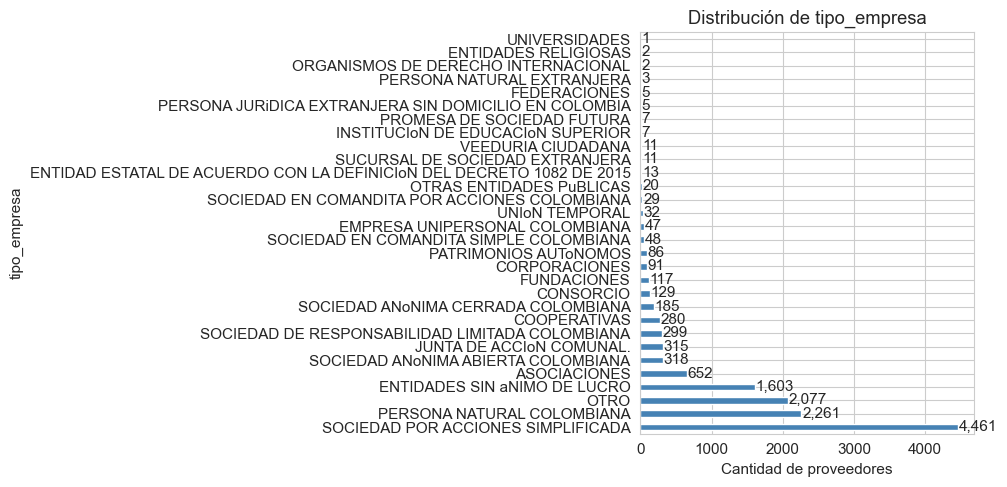

In [11]:
# Tipo de empresa
tipo_col = [c for c in df.columns if 'tipo' in c.lower() and 'empresa' in c.lower()]
if not tipo_col:
    tipo_col = [c for c in df.columns if 'tipo' in c.lower() and 'doc' not in c.lower()]

if tipo_col:
    tipo_col = tipo_col[0]
    print(f'=== {tipo_col} ===')
    dist_tipo = df[tipo_col].value_counts()
    print(dist_tipo)
    print()
    
    fig, ax = plt.subplots(figsize=(10, 5))
    dist_tipo.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Distribución de {tipo_col}')
    ax.set_xlabel('Cantidad de proveedores')
    for i, v in enumerate(dist_tipo.values):
        ax.text(v + 10, i, f'{v:,}', va='center')
    plt.tight_layout()
    plt.show()
else:
    print('Campo tipo_empresa no encontrado')

In [12]:
# Clasificación Pyme
pyme_col = [c for c in df.columns if 'pyme' in c.lower()]

if pyme_col:
    pyme_col = pyme_col[0]
    print(f'=== {pyme_col} ===')
    dist_pyme = df[pyme_col].value_counts()
    print(dist_pyme)
    print(f'\nPorcentajes:')
    print((dist_pyme / len(df) * 100).round(1))
else:
    print('Campo Pyme no encontrado')

# Es grupo
grupo_col = [c for c in df.columns if 'grupo' in c.lower()]
if grupo_col:
    grupo_col = grupo_col[0]
    print(f'\n=== {grupo_col} ===')
    print(df[grupo_col].value_counts())

# Es entidad
entidad_col = [c for c in df.columns if 'entidad' in c.lower()]
if entidad_col:
    entidad_col = entidad_col[0]
    print(f'\n=== {entidad_col} ===')
    print(df[entidad_col].value_counts())

=== espyme ===
espyme
SI    7870
NO    5247
Name: count, dtype: int64

Porcentajes:
espyme
SI    60.0
NO    40.0
Name: count, dtype: float64

=== es_grupo ===
es_grupo
No    13117
Name: count, dtype: int64

=== es_entidad ===
es_entidad
No    13115
Si        2
Name: count, dtype: int64


## 9. Ubicación geográfica

País, departamento y municipio de los proveedores de Obra.

In [13]:
# País
pais_col = [c for c in df.columns if 'pais' in c.lower() or 'país' in c.lower()]
if pais_col:
    pais_col = pais_col[0]
    n_paises = df[pais_col].nunique()
    print(f'=== {pais_col} ({n_paises} valores únicos) ===')
    top_paises = df[pais_col].value_counts().head(15)
    print(top_paises)
    
    # Porcentaje Colombia vs extranjero
    colombia_mask = df[pais_col].str.contains('Colombia|COLOMBIA|colombia', na=False)
    n_col = colombia_mask.sum()
    print(f'\nColombia: {n_col:,} ({n_col/len(df)*100:.1f}%)')
    print(f'Extranjero o sin dato: {len(df)-n_col:,} ({(len(df)-n_col)/len(df)*100:.1f}%)')
else:
    print('Campo país no encontrado')

=== pais (3 valores únicos) ===
pais
CO    13115
BE        1
US        1
Name: count, dtype: int64

Colombia: 0 (0.0%)
Extranjero o sin dato: 13,117 (100.0%)


=== departamento (36 valores únicos) ===
departamento
No Provisto                   3315
ANTIOQUIA                     1209
DISTRITO CAPITAL DE BOGOTa    1018
BOYACa                         658
SANTANDER                      604
CUNDINAMARCA                   598
META                           528
CAUCA                          464
CALDAS                         448
TOLIMA                         402
HUILA                          376
VALLE DEL CAUCA                367
MAGDALENA                      320
BOLiVAR                        304
NORTE DE SANTANDER             269
Name: count, dtype: int64


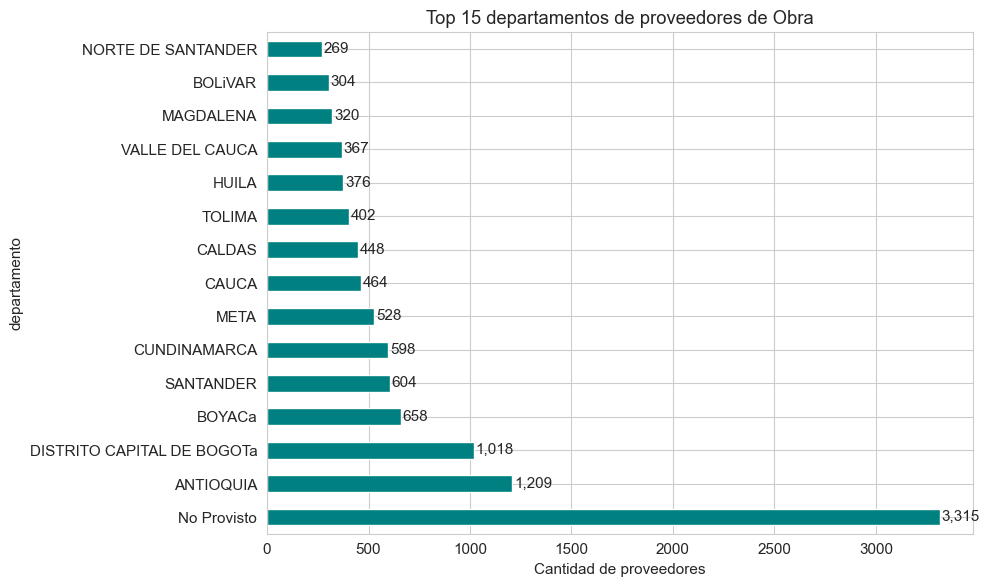

In [14]:
# Departamento
depto_col = [c for c in df.columns if 'departamento' in c.lower()]
if depto_col:
    depto_col = depto_col[0]
    n_deptos = df[depto_col].nunique()
    print(f'=== {depto_col} ({n_deptos} valores únicos) ===')
    top_deptos = df[depto_col].value_counts().head(15)
    print(top_deptos)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    top_deptos.plot(kind='barh', ax=ax, color='teal')
    ax.set_title('Top 15 departamentos de proveedores de Obra')
    ax.set_xlabel('Cantidad de proveedores')
    for i, v in enumerate(top_deptos.values):
        ax.text(v + 10, i, f'{v:,}', va='center')
    plt.tight_layout()
    plt.show()
else:
    print('Campo departamento no encontrado')

In [15]:
# Municipio
mun_col = [c for c in df.columns if 'municipio' in c.lower()]
if mun_col:
    mun_col = mun_col[0]
    n_mun = df[mun_col].nunique()
    print(f'=== {mun_col} ({n_mun} valores únicos) ===')
    top_mun = df[mun_col].value_counts().head(15)
    print(top_mun)
else:
    print('Campo municipio no encontrado')

=== municipio (708 valores únicos) ===
municipio
No Provisto      3848
BOGOTa            698
MEDELLiN          332
POPAYaN           245
IBAGUe            243
BARRANQUILLA      195
TUNJA             179
PASTO             171
VILLAVICENCIO     168
CALI              162
NEIVA             161
MANIZALES         158
CARTAGENA         140
BUCARAMANGA       139
SANTA MARTA       132
Name: count, dtype: int64


## 10. Categoría UNSPSC

Análisis de la categoría principal declarada por los proveedores.

=== descripcion_categoria_principal (69 categorías únicas) ===

descripcion_categoria_principal
No Definido                                                                    12732
Servicios profesionales de ingeniería y arquitectura                             108
Servicios de mantenimiento y reparaciones de construcciones e instalaciones       95
Servicios de construcción de edificaciones no residenciales                       21
Servicios de construcción pesada                                                  20
Servicios de mantenimiento y construcción de comercio especializado               10
Servicios de construcción de edificaciones residenciales                          10
Estructuras y edificios permanentes                                               10
Vías                                                                               8
Servicios de asesoría de gestión                                                   6
Calefacción, ventilación y circulación del aire                                    4
Gestión medioambiental           

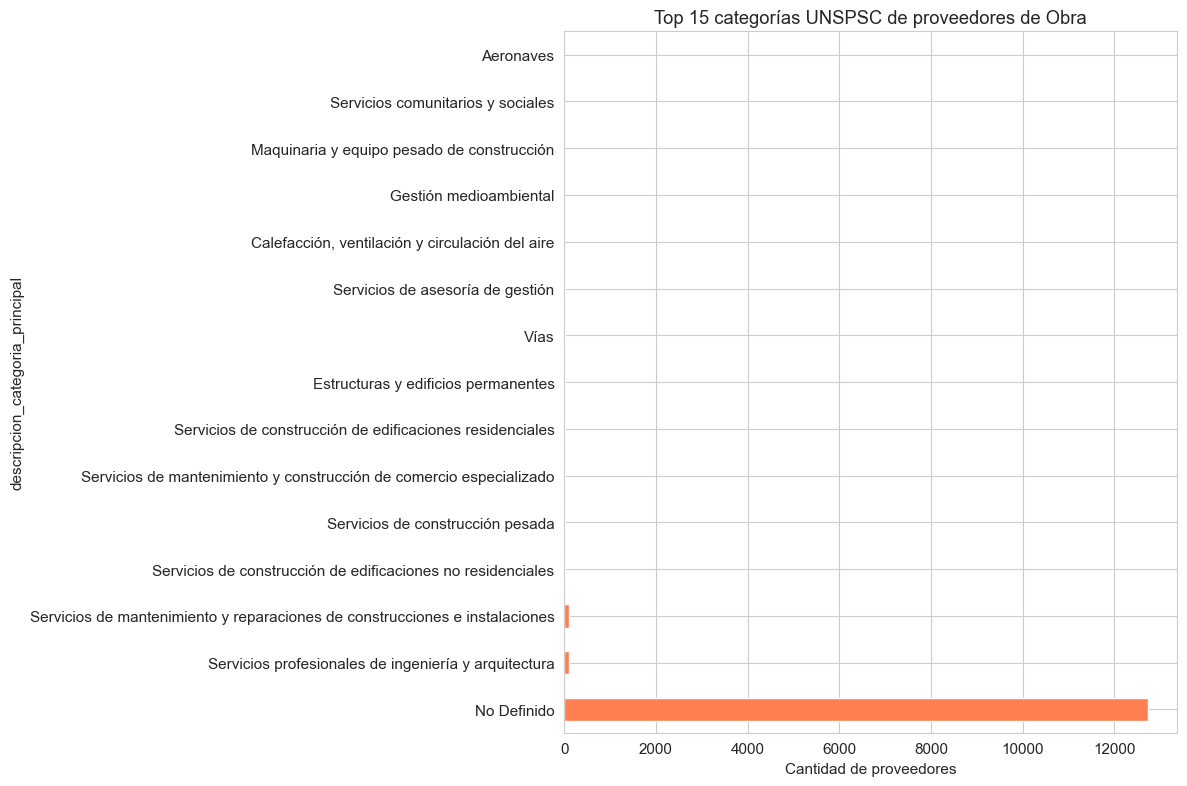

In [16]:
# Código categoría principal
cat_code_col = [c for c in df.columns if 'codigo' in c.lower() and 'categoria' in c.lower()]
cat_desc_col = [c for c in df.columns if 'descripcion' in c.lower() and 'categoria' in c.lower()]

if cat_desc_col:
    cat_desc_col = cat_desc_col[0]
    n_cats = df[cat_desc_col].nunique()
    print(f'=== {cat_desc_col} ({n_cats} categorías únicas) ===')
    top_cats = df[cat_desc_col].value_counts().head(20)
    print(top_cats)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    top_cats.head(15).plot(kind='barh', ax=ax, color='coral')
    ax.set_title('Top 15 categorías UNSPSC de proveedores de Obra')
    ax.set_xlabel('Cantidad de proveedores')
    plt.tight_layout()
    plt.show()
elif cat_code_col:
    cat_code_col = cat_code_col[0]
    print(f'=== {cat_code_col} ===')
    print(df[cat_code_col].value_counts().head(20))
else:
    print('Campo categoría no encontrado')

## 11. Análisis temporal

Fecha de creación/registro de los proveedores.

Campos de fecha encontrados: ['fecha_creacion']

=== fecha_creacion ===
Rango: 2015-02-17 00:00:00 — 2026-01-31 00:00:00
Nulos: 0


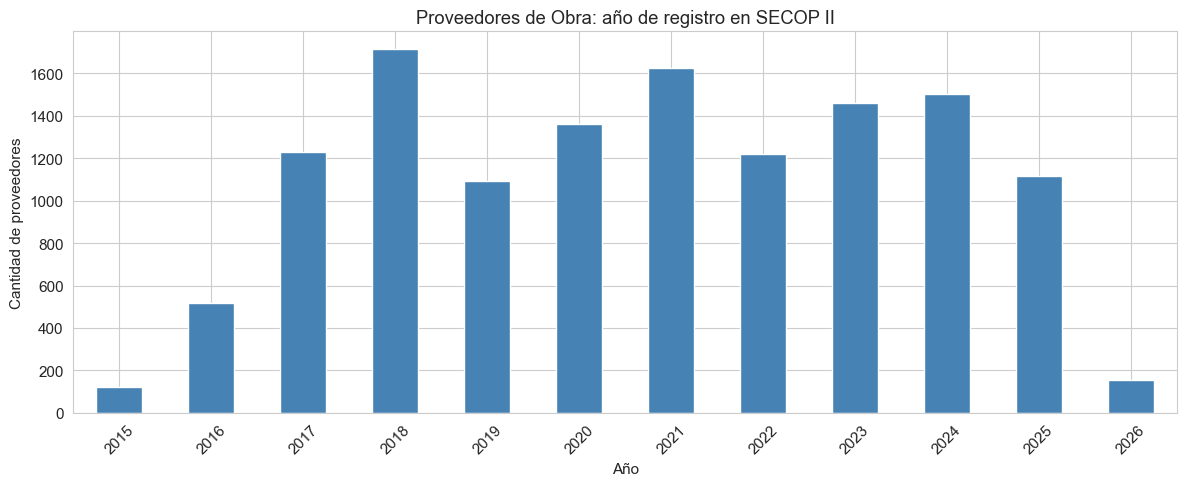

In [17]:
# Buscar campo de fecha
fecha_col = [c for c in df.columns if 'fecha' in c.lower()]
print(f'Campos de fecha encontrados: {fecha_col}')

if fecha_col:
    fecha_col = fecha_col[0]
    df[fecha_col] = pd.to_datetime(df[fecha_col], errors='coerce')
    
    print(f'\n=== {fecha_col} ===')
    print(f'Rango: {df[fecha_col].min()} — {df[fecha_col].max()}')
    print(f'Nulos: {df[fecha_col].isna().sum():,}')
    
    # Registros por año
    df['_anio_registro'] = df[fecha_col].dt.year
    dist_anio = df['_anio_registro'].value_counts().sort_index()
    
    fig, ax = plt.subplots(figsize=(12, 5))
    dist_anio.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title('Proveedores de Obra: año de registro en SECOP II')
    ax.set_xlabel('Año')
    ax.set_ylabel('Cantidad de proveedores')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Limpiar columna auxiliar
    df.drop('_anio_registro', axis=1, inplace=True)
else:
    print('No se encontraron campos de fecha')

## 12. Completitud de datos de contacto

Evaluamos la completitud de los campos de contacto y representante legal.
Estos campos **no** son features predictivos, pero nos indican la calidad del registro.

In [18]:
contacto_cols = [c for c in df.columns if any(k in c.lower() for k in 
                 ['telefono', 'teléfono', 'correo', 'direccion', 'dirección',
                  'fax', 'sitio', 'web', 'representante'])]

if contacto_cols:
    print('=== Completitud de campos de contacto ===')
    for col in contacto_cols:
        n_filled = df[col].notna().sum()
        # También descontar cadenas vacías
        if df[col].dtype == 'object':
            n_filled = (df[col].notna() & (df[col] != '')).sum()
        pct = n_filled / len(df) * 100
        print(f'  {col}: {n_filled:,} / {len(df):,} ({pct:.1f}%)')
else:
    print('No se encontraron campos de contacto')

=== Completitud de campos de contacto ===
  telefono: 13,117 / 13,117 (100.0%)
  fax: 13,117 / 13,117 (100.0%)
  correo: 13,117 / 13,117 (100.0%)
  direccion: 13,117 / 13,117 (100.0%)
  sitio_web: 13,117 / 13,117 (100.0%)
  nombre_representante_legal: 13,117 / 13,117 (100.0%)
  tipo_doc_representante_legal: 13,117 / 13,117 (100.0%)
  n_mero_doc_representante_legal: 13,117 / 13,117 (100.0%)
  telefono_representante_legal: 13,117 / 13,117 (100.0%)
  correo_representante_legal: 13,117 / 13,117 (100.0%)


## 13. Resumen de calidad

In [19]:
print('=' * 60)
print('RESUMEN DE CALIDAD — proveedoresRegistrados (Obra)')
print('=' * 60)
print(f'Registros descargados:        {len(df):,}')
print(f'Columnas:                     {len(df.columns)}')
print(f'Proveedores únicos:           {df[codigo_field].nunique():,}')

cobertura_prov = len(encontrados) / len(proveedores_obra) * 100
print(f'Cobertura vs contratos Obra:  {cobertura_prov:.1f}% ({len(encontrados):,}/{len(proveedores_obra):,})')

nul_total = df.isna().sum().sum()
total_celdas = len(df) * len(df.columns)
print(f'Nulidad global:               {nul_total:,}/{total_celdas:,} ({nul_total/total_celdas*100:.1f}%)')
print(f'Duplicados en código:         {n_dup_codigo:,}')
print(f'Filas 100% duplicadas:        {n_dup_completo:,}')

RESUMEN DE CALIDAD — proveedoresRegistrados (Obra)
Registros descargados:        13,117
Columnas:                     25
Proveedores únicos:           12,618
Cobertura vs contratos Obra:  54.4% (12,618/23,192)
Nulidad global:               0/327,925 (0.0%)
Duplicados en código:         499
Filas 100% duplicadas:        499


## 14. Clasificación de columnas

Clasificamos cada columna según su utilidad para el modelo predictivo.

In [20]:
# Clasificación por nombre de campo
clasificacion = {
    'ID / Llave': [],
    'Feature candidato': [],
    'Dato de contacto (descartar)': [],
    'Representante legal (descartar)': [],
    'Otro / Revisar': []
}

for col in df.columns:
    cl = col.lower()
    if cl in ('codigo', 'código', 'nit'):
        clasificacion['ID / Llave'].append(col)
    elif any(k in cl for k in ['tipo_empresa', 'tipoempresa', 'pyme', 'espyme',
                                 'grupo', 'entidad', 'activa', 'pais', 'país',
                                 'departamento', 'municipio', 'categoria',
                                 'fecha_creacion', 'fechacreacion', 'ubicacion', 'ubicación']):
        clasificacion['Feature candidato'].append(col)
    elif any(k in cl for k in ['representante', 'legal']):
        clasificacion['Representante legal (descartar)'].append(col)
    elif any(k in cl for k in ['telefono', 'teléfono', 'correo', 'direccion',
                                 'dirección', 'fax', 'sitio', 'web']):
        clasificacion['Dato de contacto (descartar)'].append(col)
    elif cl == 'nombre':
        clasificacion['Dato de contacto (descartar)'].append(col)
    else:
        clasificacion['Otro / Revisar'].append(col)

print('=== Clasificación de columnas ===')
for cat, cols in clasificacion.items():
    print(f'\n{cat} ({len(cols)}):')
    for c in cols:
        print(f'  - {c}')

=== Clasificación de columnas ===

ID / Llave (2):
  - codigo
  - nit

Feature candidato (12):
  - es_entidad
  - es_grupo
  - esta_activa
  - fecha_creacion
  - codigo_categoria_principal
  - descripcion_categoria_principal
  - pais
  - departamento
  - municipio
  - tipo_empresa
  - espyme
  - ubicacion

Dato de contacto (descartar) (6):
  - nombre
  - telefono
  - fax
  - correo
  - direccion
  - sitio_web

Representante legal (descartar) (5):
  - nombre_representante_legal
  - tipo_doc_representante_legal
  - n_mero_doc_representante_legal
  - telefono_representante_legal
  - correo_representante_legal

Otro / Revisar (0):


### Variables derivadas propuestas

| Variable | Origen | Tipo | Descripción |
|---|---|---|---|
| `proveedor_activo` | esta_activa | Binaria | 1 si el proveedor está activo |
| `proveedor_es_pyme` | espyme | Binaria | 1 si es Pyme |
| `proveedor_es_grupo` | es_grupo | Binaria | 1 si pertenece a grupo |
| `proveedor_tipo_empresa` | tipo_empresa | Categórica | Tipo de empresa |
| `proveedor_departamento` | departamento | Categórica | Departamento de ubicación |
| `proveedor_pais_colombia` | país | Binaria | 1 si es de Colombia |
| `proveedor_categoria_unspsc` | codigo_categoria_principal | Categórica | Categoría UNSPSC |
| `proveedor_antiguedad_dias` | fecha_creacion | Numérica | Días desde registro hasta fecha de contrato |

## 15. Guardado en Parquet

In [21]:
output_path = DATA_DIR + 'proveedores_obra.parquet'
df.to_parquet(output_path, index=False)

import os
size_mb = os.path.getsize(output_path) / (1024 * 1024)
print(f'Guardado: {output_path}')
print(f'Tamaño: {size_mb:.1f} MB')
print(f'Registros: {len(df):,}')
print(f'Columnas: {len(df.columns)}')

Guardado: ../data/proveedores_obra.parquet
Tamaño: 1.7 MB
Registros: 13,117
Columnas: 25


## 16. Conclusiones y evaluación CRISP-DM

### Hallazgos clave

1. **Cobertura parcial (54.4%)**: Solo 12,618 de 23,192 proveedores de Obra tienen registro en este dataset.
   Los 10,574 faltantes pueden ser proveedores que no completaron su perfil o que fueron eliminados del registro.

2. **Sentinela "No Provisto"**: Aunque la nulidad técnica es 0%, muchos campos usan la cadena `"No Provisto"` como placeholder.
   Esto afecta especialmente a: departamento, municipio, teléfono, fax, correo, dirección, sitio_web.

3. **País usa código ISO**: El campo `pais` contiene códigos ISO-2 (`CO`, `US`, `BE`), no nombres completos.
   99.98% son `CO` (Colombia) — variable casi constante.

4. **Variables con varianza cero o casi cero**:
   - `es_grupo` = 100% "No" → **DESCARTAR**
   - `es_entidad` = 99.98% "No" → **DESCARTAR**
   - `esta_activa` = 99.99% "Si" → **DESCARTAR**
   - `pais` = 99.98% "CO" → **DESCARTAR** (o usar solo como binaria)

5. **Features útiles identificados**:
   - `espyme` (60% SI / 40% NO) — buena distribución
   - `tipo_empresa` — SAS domina, pero hay variedad (9+ tipos)
   - `departamento` — 34 departamentos (ojo: 29% "No Provisto")
   - `municipio` — 708 municipios (ojo: 29% "No Provisto")
   - `codigo_categoria_principal` / `descripcion_categoria_principal` — categorías UNSPSC
   - `fecha_creacion` — antigüedad del proveedor en SECOP II

6. **Duplicados simples**: 499 filas 100% duplicadas → fácil deduplicar.

7. **Datos de contacto y representante legal**: 11 columnas descartables para modelado (solo sirven para identificación).

### Evaluación CRISP-DM — Fase 2: Comprensión de datos

| Criterio | Estado |
|---|---|
| Datos recolectados | 13,117 registros (12,618 proveedores únicos) |
| Cobertura | 54.4% de proveedores de Obra |
| Calidad evaluada | 0% nulidad técnica, pero centinela "No Provisto" frecuente |
| Variables clasificadas | 2 IDs + 12 features + 6 contacto + 5 representante legal |
| Variables con varianza cero | 4 columnas a descartar (es_grupo, es_entidad, esta_activa, pais) |
| Variables derivadas propuestas | 8 features del perfil del proveedor |
| Llave de integración | `codigo` → `codigo_proveedor` (54.4% cobertura) |

### Siguiente paso

Con las **4 fuentes exploradas**, el siguiente notebook será la **integración**:
JOIN de todas las fuentes usando la fuente madre (contratosElectronicos) como eje central,
feature engineering, y construcción del esquema final para modelado.